## Analyze the dataset distribution among classes.

Evaluate feature importance to compute the most important feature and remove the non important ones, then create a binary dataset so that we can work with a GAN. Actually here we may think of using another apporach, consisering multiple classes.

The inital dataset is composed by the following classes:<br>
NORMAL           17816<br>
c_rd_na_1_DoS     4974<br>
c_rp_na_1_DoS     4970<br>
c_sc_na_1_DoS     3688<br>
c_rp_na_1         2900<br>
c_rd_na_1         2720<br>
c_se_na_1_DoS     2686<br>
c_ci_na_1_DoS     1986<br>
c_se_na_1         1728<br>
c_sc_na_1         1482<br>
m_sp_na_1_DoS     1274<br>
c_ci_na_1         1140<br><br>

So we can drop the column normal and only uses the other classes.<br>

In [1]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

def save_artifacts(out_dir: Path, X_train, X_val, y_train, y_val, feat_names):
    art_dir = out_dir / "artifacts"
    art_dir.mkdir(parents=True, exist_ok=True)

    # scaler
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(X_train.values).astype(np.float32)
    Xva_scaled = scaler.transform(X_val.values).astype(np.float32)

    # salva feature list
    with open(art_dir / "features.json", "w", encoding="utf-8") as f:
        json.dump(list(feat_names), f, indent=2)

    # salva scaler
    with open(art_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    # salva CSV per GAN
    df_tr = pd.DataFrame(Xtr_scaled, columns=feat_names)
    df_tr["label"] = y_train.values.astype(np.int32)
    df_va = pd.DataFrame(Xva_scaled, columns=feat_names)
    df_va["label"] = y_val.values.astype(np.int32)
    df_tr.to_csv(out_dir / "gan_train_raw.csv", index=False)
    df_va.to_csv(out_dir / "gan_val_raw.csv", index=False)



def to_numeric_label(val):
    """0=benigno, 1=maligno. Gestisce stringhe multiclass CICFlow: tutto ciò che non è BENIGN/normal è 1."""
    v = val.lower()
    if v.endswith("dos"):
        return 1
    elif v == "normal":
        return 0
    return 2


input_csv='merged_network_flow_leayer.csv'
out_dir="."
label_col=None
topk_plot=10
test_size=0.2
random_state=42 
select_topk=10
out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)
label_col = "Label" 

df = pd.read_csv(input_csv)
df = df.dropna(axis=1, how="all")

# Le seguenti righe sono state aggiunte
#allowed_values = ['c_ci_na_1', 'c_rd_na_1', 'c_rp_na_1', 'c_sc_na_1', 'c_se_na_1']
#allowed_values = ['c_ci_na_1_DoS', 'c_rd_na_1_DoS', 'c_rp_na_1_DoS', 'c_sc_na_1_DoS', 'c_se_na_1_DoS']
allowed_values = ['c_ci_na_1', 'c_rp_na_1', 'c_sc_na_1', 'c_se_na_1', 'c_ci_na_1_DoS', 'c_rp_na_1_DoS', 'c_sc_na_1_DoS', 'c_se_na_1_DoS']

df = df[df[label_col].isin(allowed_values)]
#le = LabelEncoder()
#df[label_col] = le.fit_transform(df[label_col])

y = df[label_col].apply(to_numeric_label).astype(np.int32)
#y = df[label_col].astype(np.int32)

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

# Remove the features related to the identity of the node
DROP_IF_PRESENT = {
    "timestamp", "time", "date", "datetime", "ts", "flow_start", "flow_end",
    "src_ip", "dst_ip", "source_ip", "destination_ip",
    "src_port", "dst_port", "source_port", "destination_port",
    "sport", "dport", "proto", "protocol", "flow_id", "id", "uid", "src port"
}
feat_cols = [c for c in numeric_cols if c != label_col and c.lower() not in DROP_IF_PRESENT]

# Resolve missing types
X_full = df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

# split
Xtr_full, Xva_full, ytr, yva = train_test_split(
    X_full, y, test_size=test_size, random_state=random_state, stratify=y
)

# feature importance (sul full)
#rf = RandomForestClassifier(n_estimators=300, random_state=13, n_jobs=-1, class_weight="balanced_subsample")
rf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42, class_weight='balanced')

rf.fit(Xtr_full, ytr)
fi = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)
fi.to_csv(out_dir / "feature_importance.csv", header=["gini_importance"])

# plot top-k (per il grafico usiamo topk_plot, indipendentemente da select_topk)
plot_series = fi.head(int(topk_plot))[::-1]
plt.figure(figsize=(10, max(5, len(plot_series) * 0.3 + 2)))
plt.barh(plot_series.index, plot_series.values)
plt.xlabel("Importance")
plt.title(f"Top-{int(topk_plot)} feature importances")
plt.tight_layout()
plt.savefig(out_dir / "feature_importance_topk.png", dpi=160)
plt.close()

topk_feats = list(fi.head(select_topk).index)

# Apply the feature importance list on the dataset (both training and validation datasets)
Xtr_k = Xtr_full[topk_feats].copy()
Xva_k = Xva_full[topk_feats].copy()

# sovrascrive gli artifact GAN con la versione top-k
save_artifacts(out_dir, Xtr_k, Xva_k, ytr, yva, topk_feats)

selected_info = {
    "selected_topk": select_topk,
    "selected_features": topk_feats
}
(out_dir / "selected_topk.json").write_text(json.dumps(selected_info, indent=2), encoding="utf-8")


# meta
meta = {
    "input_csv": str(Path(input_csv).resolve()),
    "out_dir": str(out_dir.resolve()),
    "label_col": label_col,
    "n_rows": int(df.shape[0]),
    "n_features_full": int(X_full.shape[1]),
    "train_size": int(len(ytr)),
    "val_size": int(len(yva)),
    "malign_rate_train": float(np.mean(ytr)),
    "malign_rate_val": float(np.mean(yva)),
    "topk_plot": int(topk_plot),
    "select_topk": int(select_topk) if select_topk is not None else None
}
(out_dir / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

391

# Functions needed for preprocessing
Here I implemented the function for saving the artifacts and for the conversion to numeric labels.

In [2]:
df

,flow id,protocol,src ip,dst ip,src port,dst port,flow idle time max,flow idle time min,flow idle time mean,flow idle time std,...,cot=20,type_id_process_information_in_monitor_direction,type_id_process_information_in_control_direction,type_id_system_information_in_monitor_direction,type_id_system_information_in_control_direction,type_id_parameter_in_control_direction,type_id_file_transfer,Label,source_file,bw IAT std.1
1030,192.168.1.28_192.168.1.24_39845_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,39845,2404,10.016322,7.565255,9.198518,1.414448,...,0,1,0,0,2,0,0,c_rp_na_1_DoS,20200606_UOWM_IEC104_Dataset_c_rp_na_1_DoS/202...,NaN
1079,192.168.1.28_192.168.1.24_37005_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,37005,2404,10.040232,10.010317,10.025275,-1.000000,...,0,1,0,0,2,0,0,c_rp_na_1_DoS,20200606_UOWM_IEC104_Dataset_c_rp_na_1_DoS/202...,NaN
1084,192.168.1.28_192.168.1.24_38235_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,38235,2404,10.023524,10.016081,10.019803,-1.000000,...,0,1,0,0,2,0,0,c_rp_na_1_DoS,20200606_UOWM_IEC104_Dataset_c_rp_na_1_DoS/202...,NaN
1089,192.168.1.28_192.168.1.24_33703_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,33703,2404,10.027971,9.836028,9.961563,0.108777,...,0,1,0,0,2,0,0,c_rp_na_1_DoS,20200606_UOWM_IEC104_Dataset_c_rp_na_1_DoS/202...,NaN
1103,192.168.1.28_192.168.1.24_40307_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,40307,2404,10.024944,9.452793,9.830806,0.327409,...,0,1,0,0,2,0,0,c_rp_na_1_DoS,20200606_UOWM_IEC104_Dataset_c_rp_na_1_DoS/202...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45045,192.168.1.28_192.168.1.24_37689_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,37689,2404,10.013140,10.009096,10.011118,-1.000000,...,0,1,0,0,2,0,0,c_rp_na_1,20200606_UOWM_IEC104_Dataset_c_rp_na_1/2020060...,NaN
45046,192.168.1.28_192.168.1.21_46637_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.21,46637,2404,10.028102,10.012155,10.020128,-1.000000,...,0,0,0,0,2,0,0,c_rp_na_1,20200606_UOWM_IEC104_Dataset_c_rp_na_1/2020060...,NaN
45047,192.168.1.28_192.168.1.24_39397_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,39397,2404,10.018228,10.012116,10.015172,-1.000000,...,0,0,0,0,2,0,0,c_rp_na_1,20200606_UOWM_IEC104_Dataset_c_rp_na_1/2020060...,NaN
45048,192.168.1.28_192.168.1.24_38257_2404_IEC60870-...,IEC-60870-5-104,192.168.1.28,192.168.1.24,38257,2404,10.009612,10.007602,10.008607,-1.000000,...,0,0,0,0,2,0,0,c_rp_na_1,20200606_UOWM_IEC104_Dataset_c_rp_na_1/2020060...,NaN


In [3]:
import os
import json
import pickle
from pathlib import Path
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
def save_artifacts(out_dir: Path, X_train, X_val, y_train, y_val, feat_names):
    art_dir = out_dir / "artifacts"
    art_dir.mkdir(parents=True, exist_ok=True)

    # scaler
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(X_train.values).astype(np.float32)
    Xva_scaled = scaler.transform(X_val.values).astype(np.float32)

    # salva feature list
    with open(art_dir / "features.json", "w", encoding="utf-8") as f:
        json.dump(list(feat_names), f, indent=2)

    # salva scaler
    with open(art_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    # salva CSV per GAN
    df_tr = pd.DataFrame(Xtr_scaled, columns=feat_names)
    df_tr["label"] = y_train.values.astype(np.int32)
    df_va = pd.DataFrame(Xva_scaled, columns=feat_names)
    df_va["label"] = y_val.values.astype(np.int32)
    df_tr.to_csv(out_dir / "gan_train_raw.csv", index=False)
    df_va.to_csv(out_dir / "gan_val_raw.csv", index=False)



def to_numeric_label(val):
    """0=benigno, 1=maligno. Gestisce stringhe multiclass CICFlow: tutto ciò che non è BENIGN/normal è 1."""
    v = val.lower()
    if v.endswith("dos"):
        return 1
    elif v == "normal":
        return 0
    return 2


# Approach using SHAP for features importance

Here I compute the SHAP value using a Tree-based classifier.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler, SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

input_csv='merged_network_flow_leayer.csv'
out_dir="."
label_col=None
topk_plot=15
test_size=0.2
random_state=42 
select_topk=15
out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)
label_col = "Label" 

df = pd.read_csv(input_csv)
df = df.dropna(axis=1, how="all")

# Le seguenti righe sono state aggiunte
#allowed_values = ['c_ci_na_1', 'c_rd_na_1', 'c_rp_na_1', 'c_sc_na_1', 'c_se_na_1']
#allowed_values = ['c_ci_na_1_DoS', 'c_rd_na_1_DoS', 'c_rp_na_1_DoS', 'c_sc_na_1_DoS', 'c_se_na_1_DoS']
allowed_values = ['NORMAL', 'c_rp_na_1', 'c_sc_na_1', 'c_se_na_1', 'c_rp_na_1', 'c_rd_na_1', 'c_ci_na_1_DoS', 'c_sc_na_1_DoS', 'c_se_na_1_DoS']
df = df[df[label_col].isin(allowed_values)]
y = df[label_col].apply(to_numeric_label).astype(np.int32)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

# Remove the features related to the identity of the node before to compute the feature importance
DROP_IF_PRESENT = {
    "timestamp", "time", "date", "datetime", "ts", "flow_start", "flow_end",
    "src_ip", "dst_ip", "source_ip", "destination_ip",
    "src_port", "dst port", "source_port", "destination_port",
    "sport", "dport", "proto", "protocol", "flow_id", "id", "uid", "src port"
}
feat_cols = [c for c in numeric_cols if c != label_col and c.lower() not in DROP_IF_PRESENT]

# Resolve missing types
X_full = df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

# split
Xtr_full, Xva_full, ytr, yva = train_test_split(
    X_full, y, test_size=test_size, random_state=random_state, stratify=y
)

# --- Opzione B: SMOTE (Consigliata) ---
smote = SMOTE(random_state=42)
#Xtr_full, ytr = smote.fit_resample(Xtr_full, ytr)
scaler = StandardScaler()
Xtr_full = scaler.fit_transform(Xtr_full.values).astype(np.float32)
Xva_full = scaler.transform(Xva_full.values).astype(np.float32)

#print(f"Dopo il resampling (Train): {Counter(y_train_res)}")
# Output: Counter({0: 719, 1: 719}) -> Ora sono pari!

# feature importance (sul full)
#rf = RandomForestClassifier(n_estimators=300, max_depth=24, random_state=42, n_jobs=-1)
#rf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42, class_weight='balanced')
#rf = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced')
rf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=24,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

rf.fit(Xtr_full, ytr)

# predizione probabilità (utile per ROC/AUC)
y_pred = rf.predict(Xva_full)
# Accuracy
acc = accuracy_score(yva, y_pred)
print(f"Accuracy: {acc:.3f}")

# Precision / Recall / F1
# 'macro' calcola media tra classi (utile multiclass)
precision = precision_score(yva, y_pred, average='macro')
recall = recall_score(yva, y_pred, average='macro')
f1 = f1_score(yva, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.940
Precision: 0.920
Recall: 0.920
F1-score: 0.919


# Load the explainer

In [5]:
import joblib

explainer = joblib.load("shap_explainer.joblib")
shap_values = explainer.shap_values(Xva_full, check_additivity=False)

# Create dataframe for feature importance
df_importance = pd.DataFrame({
    'feature_name': Xva_full.columns,
    'importance_score': np.abs(shap_values[:,:,1]).mean(axis=0)
})
fi = df_importance.sort_values(by='importance_score', ascending=False)
top_features_list = fi['feature_name'].tolist()

# Save feature importance
fi.to_csv(out_dir / "feature_importance.csv", index=False)
plot_series = fi.head(int(topk_plot)).iloc[::-1]

# Generate and save the figure for feature importance
plt.figure(figsize=(10, 6))
plt.barh(plot_series['feature_name'], plot_series['importance_score'], color='skyblue')
plt.xlabel("Average impact on model output magnitude")
plt.title("")
plt.tight_layout()
plt.savefig(out_dir / "feature_importance_topk.png", dpi=160)
plt.close()

# Select subset of feature improtance
topk_feats = list(fi.head(select_topk)['feature_name']) # Assicuriamoci di prendere solo i nomi
print(f"Feature selezionate ({len(topk_feats)}): {topk_feats}")

# Apply selection of subset of features to dataset
Xtr_k = Xtr_full[topk_feats].copy()
Xva_k = Xva_full[topk_feats].copy()

# Save the reduced dataset
save_artifacts(out_dir, Xtr_k, Xva_k, ytr, yva, topk_feats)

selected_info = {
    "selected_topk": select_topk,
    "selected_features": topk_feats
}
(out_dir / "selected_topk.json").write_text(json.dumps(selected_info, indent=2), encoding="utf-8")

# meta
meta = {
    "input_csv": str(Path(input_csv).resolve()),
    "out_dir": str(out_dir.resolve()),
    "label_col": label_col,
    "n_rows": int(df.shape[0]),
    "n_features_full": int(X_full.shape[1]),
    "train_size": int(len(ytr)),
    "val_size": int(len(yva)),
    "malign_rate_train": float(np.mean(ytr)),
    "malign_rate_val": float(np.mean(yva)),
    "topk_plot": int(topk_plot),
    "select_topk": int(select_topk) if select_topk is not None else None
}
(out_dir / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

 99%|===================| 13825/14004 [00:47<00:00]        

Feature selezionate (15): ['flow total IEC104_S_Message packets', 'init bw window bytes', 'init fw window bytes', 'flow total IEC104_U_Message packets', 'flow ACK flag count', 'flow PSH flag count', 'total flow packets', 'bw total IEC104_U_Message packets', 'fw_subflow_bytes', 'fw_subflow_packets', 'flow packet APDU length var', 'fw IAT std', 'fw total IEC104_U_Message packets', 'total fw packets', 'fw packets APDU total length']


391

In [6]:
# predizione probabilità (utile per ROC/AUC)
rf = RandomForestClassifier(n_estimators=300, max_depth=24, random_state=42, n_jobs=-1)
rf.fit(Xtr_k, ytr)

y_pred = rf.predict(Xva_k)
# Accuracy
acc = accuracy_score(yva, y_pred)
print(f"Accuracy: {acc:.3f}")

# Precision / Recall / F1
# 'macro' calcola media tra classi (utile multiclass)
precision = precision_score(yva, y_pred, average='macro')
recall = recall_score(yva, y_pred, average='macro')
f1 = f1_score(yva, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.925
Precision: 0.911
Recall: 0.900
F1-score: 0.897


In [7]:
import os, json
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# 1) salva il modello
joblib.dump(rf, ARTIFACTS_DIR / "rf_model.pkl")

# 2) salva l'ordine delle feature (IMPORTANTISSIMO)
# se Xtr_full è un DataFrame, questo è l'ordine usato in fit/predict
features_order = list(Xtr_k.columns)
(ARTIFACTS_DIR / "features.json").write_text(
    json.dumps(features_order, indent=2),
    encoding="utf-8"
)

print("Saved:", ARTIFACTS_DIR / "rf_model_three.pkl")
print("Saved:", ARTIFACTS_DIR / "features_three.json")

Saved: artifacts/rf_model_three.pkl
Saved: artifacts/features_three.json


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(yva, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues', values_format='d')

# Save figure
plt.tight_layout()
plt.savefig("confusion_matrix.pdf", format="pdf", bbox_inches="tight")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.close()


In [ ]:
# 1. Installazione
# pip install interpret

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

# 2. Inizializzazione (simile a RandomForestClassifier)
ebm = ExplainableBoostingClassifier()

# 3. Training
ebm.fit(Xtr_full, ytr)

# 4. La "Magia": Visualizzare il modello globale
ebm_global = ebm.explain_global()
show(ebm_global) 
# Questo apre una dashboard interattiva dove puoi cliccare 
# su ogni variabile e vedere il suo grafico di impatto.

In [24]:
explainer = shap.TreeExplainer(rf, data=Xtr_full.sample(n=500, random_state=1))
shap_values = explainer.shap_values(Xva_full, check_additivity=False)

 98%|===================| 18094/18436 [00:50<00:00]        

In [25]:
import joblib
joblib.dump(explainer, "shap_explainer.joblib")
explainer_loaded = joblib.load("shap_explainer.joblib")

In [27]:
# Create dataframe for feature importance
df_importance = pd.DataFrame({
    'feature_name': Xva_full.columns,
    'importance_score': np.abs(shap_values[:,:,1]).mean(axis=0)
})
fi = df_importance.sort_values(by='importance_score', ascending=False)
top_features_list = fi['feature_name'].tolist()

# Save feature importance
fi.to_csv(out_dir / "feature_importance.csv", index=False)
plot_series = fi.head(int(topk_plot)).iloc[::-1]

# Generate and save the figure for feature importance
plt.figure(figsize=(10, 6))
plt.barh(plot_series['feature_name'], plot_series['importance_score'], color='skyblue')
plt.xlabel("Average impact on model output magnitude")
plt.title("")
plt.tight_layout()
plt.savefig(out_dir / "feature_importance_topk.png", dpi=160)
plt.close()

# Select subset of feature improtance
topk_feats = list(fi.head(select_topk)['feature_name']) # Assicuriamoci di prendere solo i nomi
print(f"Feature selezionate ({len(topk_feats)}): {topk_feats}")

# Apply selection of subset of features to dataset
Xtr_k = Xtr_full[topk_feats].copy()
Xva_k = Xva_full[topk_feats].copy()

# Save the reduced dataset
save_artifacts(out_dir, Xtr_k, Xva_k, ytr, yva, topk_feats)

selected_info = {
    "selected_topk": select_topk,
    "selected_features": topk_feats
}
(out_dir / "selected_topk.json").write_text(json.dumps(selected_info, indent=2), encoding="utf-8")

# meta
meta = {
    "input_csv": str(Path(input_csv).resolve()),
    "out_dir": str(out_dir.resolve()),
    "label_col": label_col,
    "n_rows": int(df.shape[0]),
    "n_features_full": int(X_full.shape[1]),
    "train_size": int(len(ytr)),
    "val_size": int(len(yva)),
    "malign_rate_train": float(np.mean(ytr)),
    "malign_rate_val": float(np.mean(yva)),
    "topk_plot": int(topk_plot),
    "select_topk": int(select_topk) if select_topk is not None else None
}
(out_dir / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

Feature selezionate (10): ['flow total IEC104_S_Message packets', 'init bw window bytes', 'init fw window bytes', 'flow total IEC104_U_Message packets', 'flow ACK flag count', 'flow PSH flag count', 'total flow packets', 'bw total IEC104_U_Message packets', 'fw_subflow_bytes', 'fw_subflow_packets']


391

Import all the libraries needed for the ML.

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### ML Step
Define the clas for the Model, Dataset and related train and evaluation functions.

Let's try with Deep Learning

In [52]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y
        
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dims=[128,64], dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class TabularResBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(dim)
        self.bn2 = nn.BatchNorm1d(dim)

    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.drop(out)

        out = self.fc2(out)
        out = self.bn2(out)

        return self.act(out + identity)   # skip connection
        
class TabularResNet(nn.Module):
    def __init__(self, in_dim, out_dim=2, hidden_dim=128, num_blocks=4, dropout=0.1):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        self.blocks = nn.Sequential(*[
            TabularResBlock(hidden_dim, dropout=dropout)
            for _ in range(num_blocks)
        ])

        self.output_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        x = self.output_layer(x)
        return x

# --- Definizione modello ---
class MultiClassNN(nn.Module):

    
    def __init__(self, input_dim, num_classes):
        super(MultiClassNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)  # output layer senza softmax
        )
    
    def forward(self, x):
        return self.net(x)


# ---------------- Training loop ----------------
def train_epoch(model, loader, opt, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def eval_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            pred = out.argmax(dim=1).cpu().numpy()
            
            total_loss += loss.item() * xb.size(0)
            preds.append(pred)
            trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return total_loss / len(loader.dataset), preds, trues


In [ ]:
import torch.optim as optim

out_dir="."
CSV_PATH_TRAIN = out_dir + "/gan_train_raw.csv"        # percorso al CSV (se non esiste genera dataset sintetico)
CSV_PATH_TEST = out_dir + "/gan_val_raw.csv"        # percorso al CSV (se non esiste genera dataset sintetico)
TARGET_COL = "label"         # nome colonna target
ID_COL = None                # se hai una colonna id che vuoi escludere, mettila qui (es: "id")
TEST_SIZE = 0.2
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3
MODEL_OUT = "tabular_model.pt"
META_OUT = "tabular_meta.joblib"
device = "cuda"
df = pd.read_csv(CSV_PATH_TRAIN)
df_val = pd.read_csv(CSV_PATH_TEST)

Xdf = df.drop(columns=[TARGET_COL]).copy()
ydf = df[TARGET_COL].copy()
XdfVal = df_val.drop(columns=[TARGET_COL]).copy()
ydfVal = df_val[TARGET_COL].copy()

# handle categorical columns: simple one-hot for small cardinality
cat_cols = Xdf.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()

Xdf = pd.get_dummies(Xdf, columns=cat_cols, drop_first=True)
XdfVal = pd.get_dummies(XdfVal, columns=cat_cols, drop_first=True)

# Imputer + Scaler
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_num = imputer.fit_transform(Xdf.values)
XVal_num = imputer.transform(XdfVal.values)
X_scaled = scaler.fit_transform(X_num)
XVal_scaled = scaler.transform(XVal_num)

train_ds = TabularDataset(X_scaled, ydf)
val_ds = TabularDataset(XVal_scaled, ydfVal)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# It is already an int, but keep the cast here
y_train = ydf.values.astype(int)

print("Shape X_train:", Xdf.shape, "X_val:", XdfVal.shape)

model = TabularResNet(
    in_dim=X_num.shape[1],
    out_dim=2,
    hidden_dim=128,
    num_blocks=4,   # puoi aumentare
    dropout=0.1
).to(device)


# --- Loss e ottimizzatore ---
criterion = nn.CrossEntropyLoss()  # multi-class
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float("inf")
for ep in range(1, EPOCHS+1):
    tr_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_preds, val_trues = eval_model(model, val_loader, criterion)
    if ep % 5 == 0 or ep==1:
        print(f"Epoch {ep:02d}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUT)
    

acc = accuracy_score(val_trues, val_preds)
print(f"Validation accuracy: {acc:.4f}")
print("Classification report:")
print(classification_report(val_trues, val_preds, digits=4))
meta = {
    "imputer": imputer,
    "scaler": scaler,
    "feature_columns": Xdf.columns.tolist()
}
joblib.dump(meta, META_OUT)
print("Salvati:", MODEL_OUT, META_OUT)

Shape X_train: (16464, 10) X_val: (4116, 10)
Epoch 01  train_loss=0.6548  val_loss=0.6456


Let's print the confusion matrix.

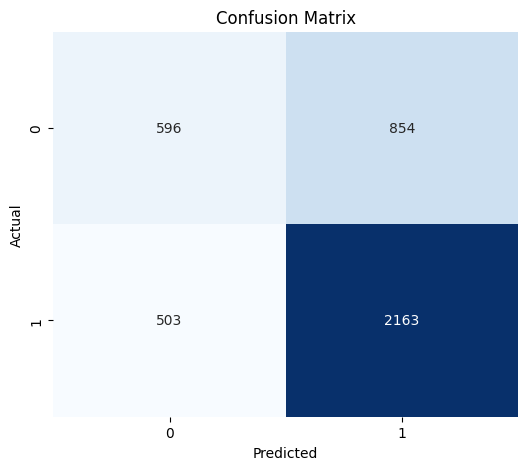

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Calcola la confusion matrix
cm = confusion_matrix(val_trues, val_preds)

# Trasforma in DataFrame per etichette leggibili
cm_df = pd.DataFrame(cm, index=["0", "1"], columns=["0", "1"])

# Plot grafico
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Example: train RF and compute SHAP explanations (offline)
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import joblib

# --- TRAINING (example) ---
rf = RandomForestClassifier(n_estimators=600, max_depth=24, random_state=24, n_jobs=-1)
rf.fit(Xdf, ydf)

# save model
joblib.dump(rf, "rf_iec104.joblib")

['rf_iec104.joblib']

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# predizione classi
y_pred = rf.predict(XdfVal)

# predizione probabilità (utile per ROC/AUC)
y_prob = rf.predict_proba(XdfVal)
# Accuracy
acc = accuracy_score(ydfVal, y_pred)
print(f"Accuracy: {acc:.3f}")

# Precision / Recall / F1
# 'macro' calcola media tra classi (utile multiclass)
precision = precision_score(ydfVal, y_pred, average='macro')
recall = recall_score(ydfVal, y_pred, average='macro')
f1 = f1_score(ydfVal, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.751
Precision: 0.729
Recall: 0.707
F1-score: 0.715


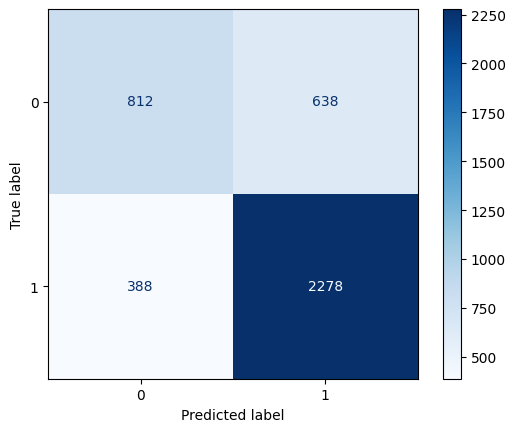

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(ydfVal, y_pred)
# Plot nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues')

Let's try with a decision tree

Accuratezza del modello: 0.58 (ovvero 57.6530612244898%)


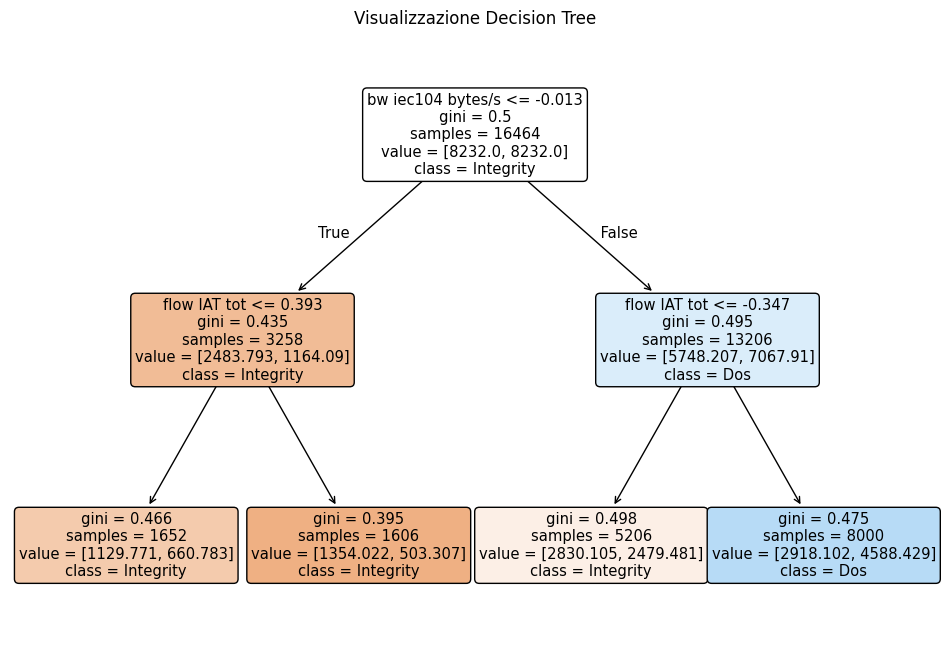

<Figure size 800x600 with 0 Axes>

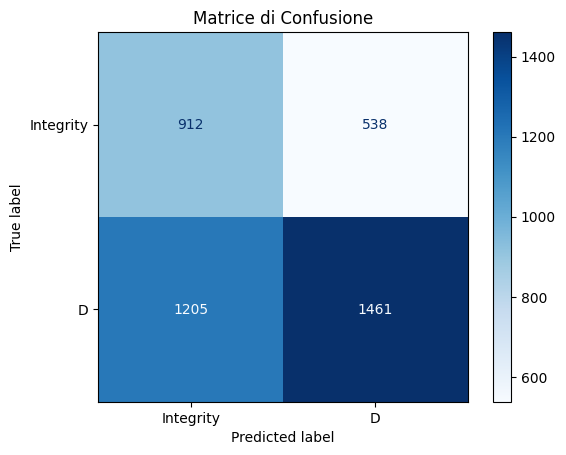

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
clf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42, class_weight='balanced')
clf.fit(Xdf, ydf)

# 4. Predizione sui dati di test
y_pred = clf.predict(XdfVal)

# 5. Valutazione del modello
accuracy = accuracy_score(ydfVal, y_pred)
print(f"Accuratezza del modello: {accuracy:.2f} (ovvero {accuracy*100}%)")

# 6. Visualizzazione dell'albero decisionale
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          filled=True, 
          feature_names=XdfVal.columns, 
          class_names=["Integrity", "Dos"],
          rounded=True)
plt.title("Visualizzazione Decision Tree")
plt.show()
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    clf, 
    XdfVal, 
    ydfVal, 
    display_labels=["Integrity", "D"], # Mette i nomi dei fiori invece di 0,1,2
    cmap='Blues' # Colora la mappa in tonalità di blu
)
plt.title("Matrice di Confusione")
plt.show()

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarizza le etichette reali (ydfVal)
# Sostituisci [0, 1, 2] con le tue classi reali
classes = np.unique(ydfVal)
y_test_binarized = label_binarize(ydfVal, classes=classes)
n_classes = y_test_binarized.shape[1]

# 2. Calcola ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # y_prob deve essere la matrice delle probabilità (n_samples, n_classes)
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plotta tutto
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange'] # Aggiungi colori se hai più classi
label = ["Normal", "Integrity", "Availability"]
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC class {0} (area = {1:0.2f})'.format(label[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('')
plt.legend(loc="lower right")

plt.savefig("roc_figure_plot.png", bbox_inches='tight', dpi=300)

# Chiudi la figura per liberare memoria
plt.close()


In [12]:
explainer = shap.TreeExplainer(rf, data=Xdf.sample(n=500, random_state=1))

In [13]:
shap_values_val = explainer.shap_values(XdfVal, check_additivity=False)

100%|===================| 8230/8234 [33:08<00:00]        

Ricorda di vedere i valori della colonna delle feature e stampa i valori e il confronto tra le due classi per capire qual è l'impatto delle feature

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 10))

shortened_names = [
    'Tot Fl S-Msg Pkts', 'Fl ACK Flg Cnt', 'Tot Fl U-Msg Pkts', 'Tot Fl Pkts',
    'Fl PSH Flg Cnt', 'Fw IAT Avg', 'Bw IAT Tot', 'Fw IAT Min',
    'Bw Tot U-Msg Pkts', 'Bw PSH Flg Amt', 'Fw IAT Tot', 'Fw PSH Flg Amt',
    'Tot Bw Pkts', 'Tot Fw Pkts', 'Fl IAT Tot', 'Bw 104 Pps',
    'Fl IAT Max', 'Bw 104 Bps', 'Fl IAT Std', 'Bw IAT Max',
    'Fl Idle Max', 'Fl Idle Min', 'Fw IAT Std', 'Fl Dur',
    'Fl IAT Min', 'Fl Act Std', 'Fl Act Max', 'Fl Act Var',
    'Bw IAT Min', 'Fl Idle Avg', 'Fl Act Avg', 'Fl 104 Bps',
    'Bw IAT Std', 'Fw TCP Tot Hdr Len', 'Fw IAT Max', 'Fw 104 Bps',
    'Fl IAT Avg', 'Fl 104 Pps', 'Fw 104 Pps', 'Fl Idle Var',
    'Fl Idle Std', 'Fl Act Min', 'Fw Pkts APDU Tot Len', 'Bw IAT Std',
    'Fw Tot U-Msg Pkts', 'Fw Subflow Pkts', 'Fl D/U Ratio', 'Bw IAT Avg',
    'Fl Pkts APDU Tot Len', 'Bw Pkt APDU Len Avg'
]
# Seleziona: Tutte le righe (:), Tutte le feature (:), Classe 1 (1)
class_index = 1

# Slicing corretto per oggetti 3D
shap_values_class_1 = shap_values_val[:, :, class_index]

# Ora puoi plottare
shap.summary_plot(shap_values_class_1, XdfVal, feature_names=shortened_names, show=False)
plt.savefig("shap_summary_class0_plot.png", bbox_inches='tight', dpi=300)

# Chiudi la figura per liberare memoria
plt.close()

# Save per-instance SHAP values for offline analysis / forensics
shap_df = pd.DataFrame(shap_values_class_1, columns=XdfVal.columns, index=XdfVal.index)
shap_df.to_parquet("shap_vals_val_class1.parquet")  # compact storage

In [ ]:
XdfVal.columns

In [73]:
XdfVal.columns

Index(['flow total IEC104_S_Message packets', 'flow ACK flag count',
       'flow total IEC104_U_Message packets', 'total flow packets',
       'flow PSH flag count', 'fw IAT mean', 'bw IAT tot', 'fw IAT min',
       'bw total IEC104_U_Message packets', 'bw PSH flag amount', 'fw iAT tot',
       'fw PSH flag amount', 'total bw packets', 'total fw packets',
       'flow IAT tot', 'bw iec104 packts/s', 'flow IAT max',
       'bw iec104 bytes/s', 'flow IAT std', 'bw IAT max'],
      dtype='object')